In [1]:
import os

import numpy as np
import geopandas as gpd
import pyproj

from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import DBSCAN, KMeans
from pointpats import centrography, distance_statistics, QStatistic

import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
import seaborn as sns
import contextily as ctx
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
Puntos = r"C:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\Data\Puntos\Base_datos_Completa.shp"
gdf = gpd.read_file(Puntos)
#gdf.info()
#print(gdf.crs)
gdf.set_crs(epsg=4326, inplace=True)
gdf["PERSONAS_A"].max()
gdf_proyectado = gdf.to_crs(epsg=3857)
gdf_ON = gdf.to_crs(epsg=9377)

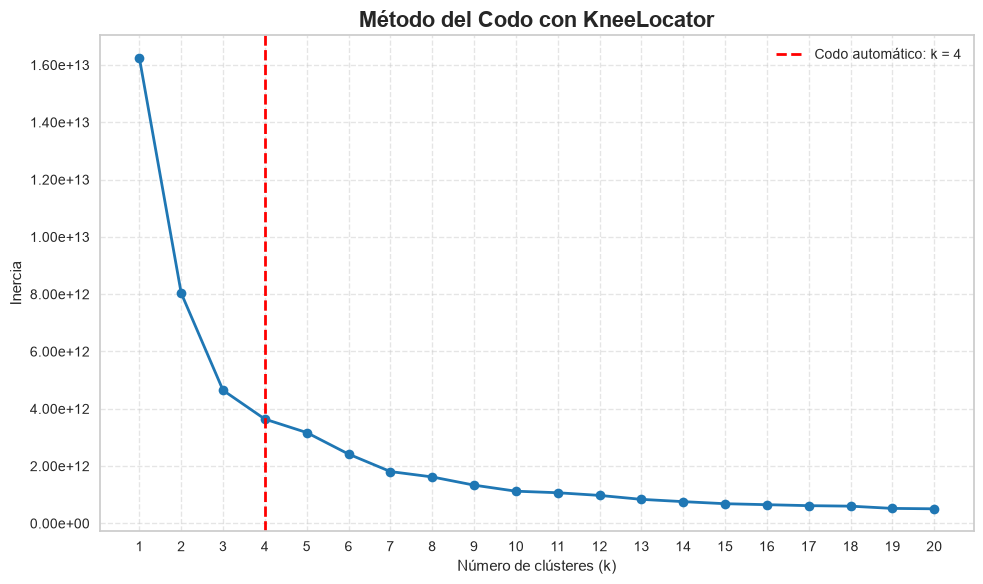

k óptimo según KneeLocator: 4


In [8]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
import matplotlib.pyplot as plt
import numpy as np

coordenadas = np.column_stack((
    gdf_ON.geometry.centroid.x,
    gdf_ON.geometry.centroid.y
))

def elbow_kneelocator(datos, max_clusters=20):

    inercias = []
    k_values = range(1, max_clusters + 1)

    for k in k_values:
        kmeans = KMeans(
            n_clusters=k,
            n_init="auto",
            random_state=42
        )
        kmeans.fit(datos)
        inercias.append(kmeans.inertia_)

    knee = KneeLocator(
        list(k_values),
        inercias,
        curve="convex",
        direction="decreasing"
    )

    k_optimo = knee.knee

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(
        k_values,
        inercias,
        marker="o",
        linewidth=2,
        color="#1f77b4"
    )

    if k_optimo is not None:
        ax.axvline(
            k_optimo,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Codo automático: k = {k_optimo}"
        )

    ax.set_title("Método del Codo con KneeLocator", fontsize=16, fontweight="bold")
    ax.set_xlabel("Número de clústeres (k)")
    ax.set_ylabel("Inercia")
    ax.set_xticks(list(k_values))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.2e}".format(x)))
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()

    plt.tight_layout()
    plt.show()

    print("k óptimo según KneeLocator:", k_optimo)

    return k_optimo, inercias

k_optimo, inercias = elbow_kneelocator(coordenadas, max_clusters=20)

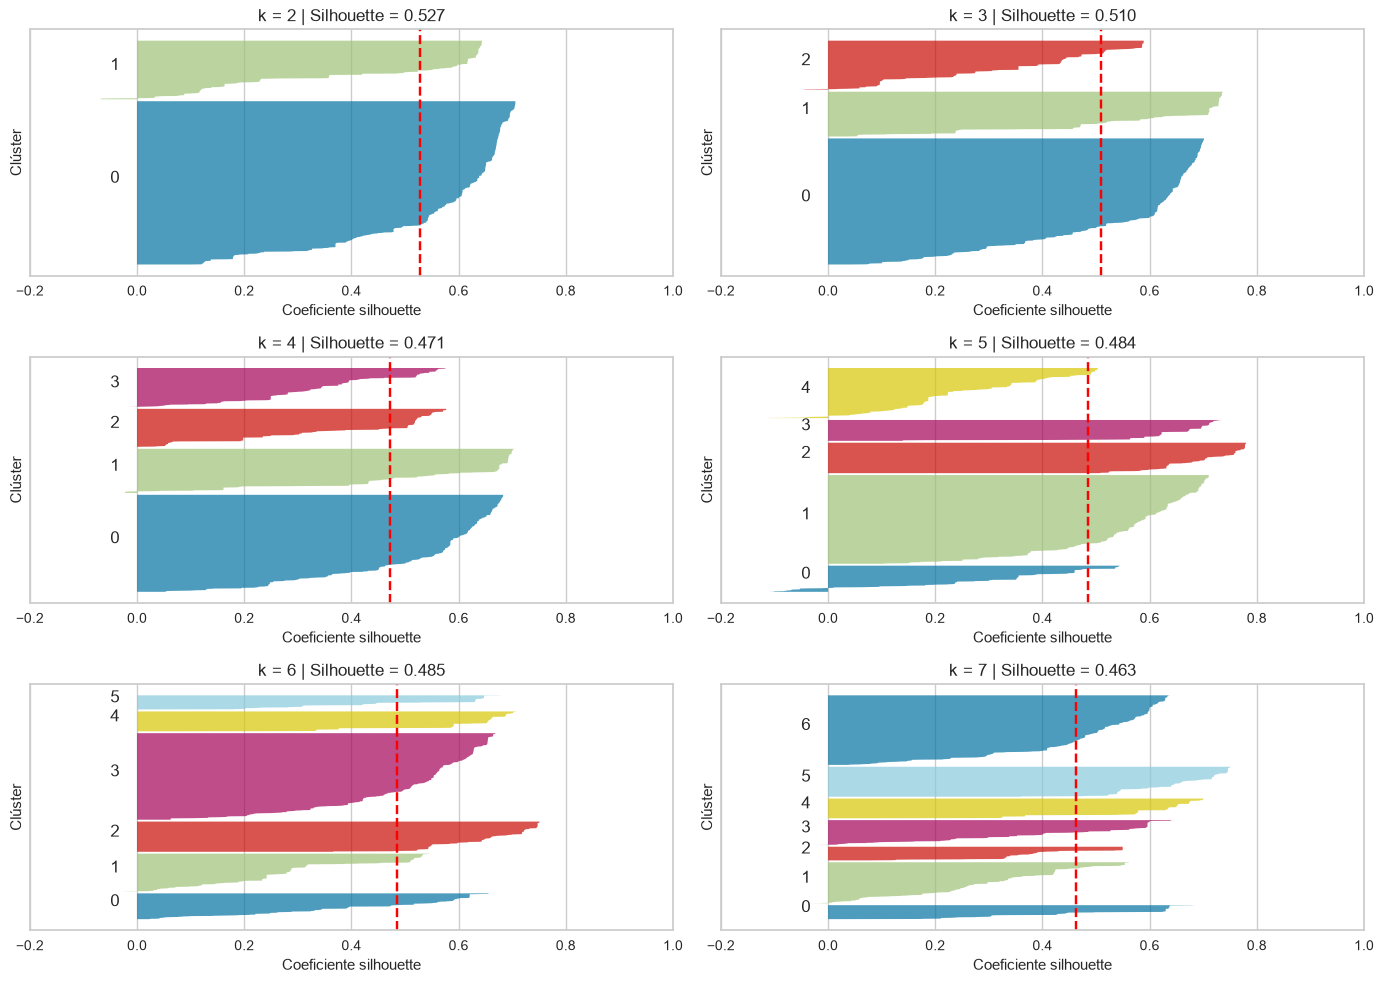

,k,Silhouette
0,2,0.527220
1,3,0.509580
2,4,0.471094
3,5,0.484122
4,6,0.484728
5,7,0.463022


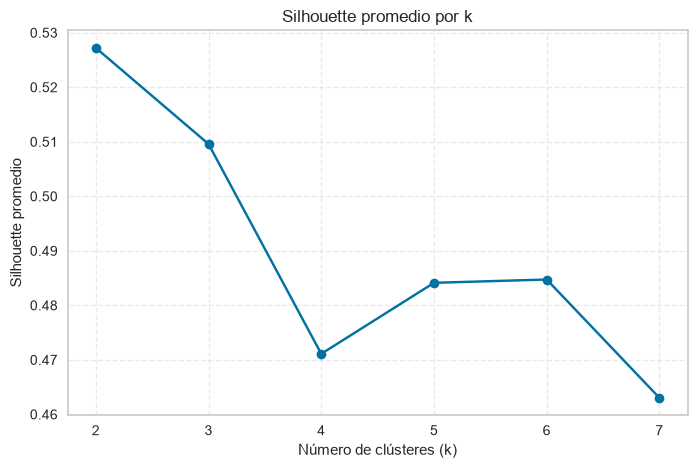

Mejor k:


k             2.00000
Silhouette    0.52722
Name: 0, dtype: float64

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

coordenadas = np.column_stack((
    gdf_ON.geometry.centroid.x,
    gdf_ON.geometry.centroid.y
))

k_values = range(2, 8)
sil_scores = []

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, k in enumerate(k_values):

    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(coordenadas)

    sil_avg = silhouette_score(coordenadas, labels)
    sil_values = silhouette_samples(coordenadas, labels)
    sil_scores.append(sil_avg)

    ax = axes[idx]
    y_lower = 10

    for cluster in range(k):
        vals = sil_values[labels == cluster]
        vals.sort()

        y_upper = y_lower + len(vals)

        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            vals,
            alpha=0.7
        )

        ax.text(-0.05, y_lower + 0.5 * len(vals), str(cluster))
        y_lower = y_upper + 10

    ax.axvline(sil_avg, color="red", linestyle="--")
    ax.set_title(f"k = {k} | Silhouette = {sil_avg:.3f}")
    ax.set_xlabel("Coeficiente silhouette")
    ax.set_ylabel("Clúster")
    ax.set_xlim([-0.2, 1])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

tabla_silhouette = pd.DataFrame({
    "k": list(k_values),
    "Silhouette": sil_scores
})

display(tabla_silhouette)

plt.figure(figsize=(8, 5))
plt.plot(tabla_silhouette["k"], tabla_silhouette["Silhouette"], marker="o")
plt.xlabel("Número de clústeres (k)")
plt.ylabel("Silhouette promedio")
plt.title("Silhouette promedio por k")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

print("Mejor k:")
display(tabla_silhouette.loc[tabla_silhouette["Silhouette"].idxmax()])

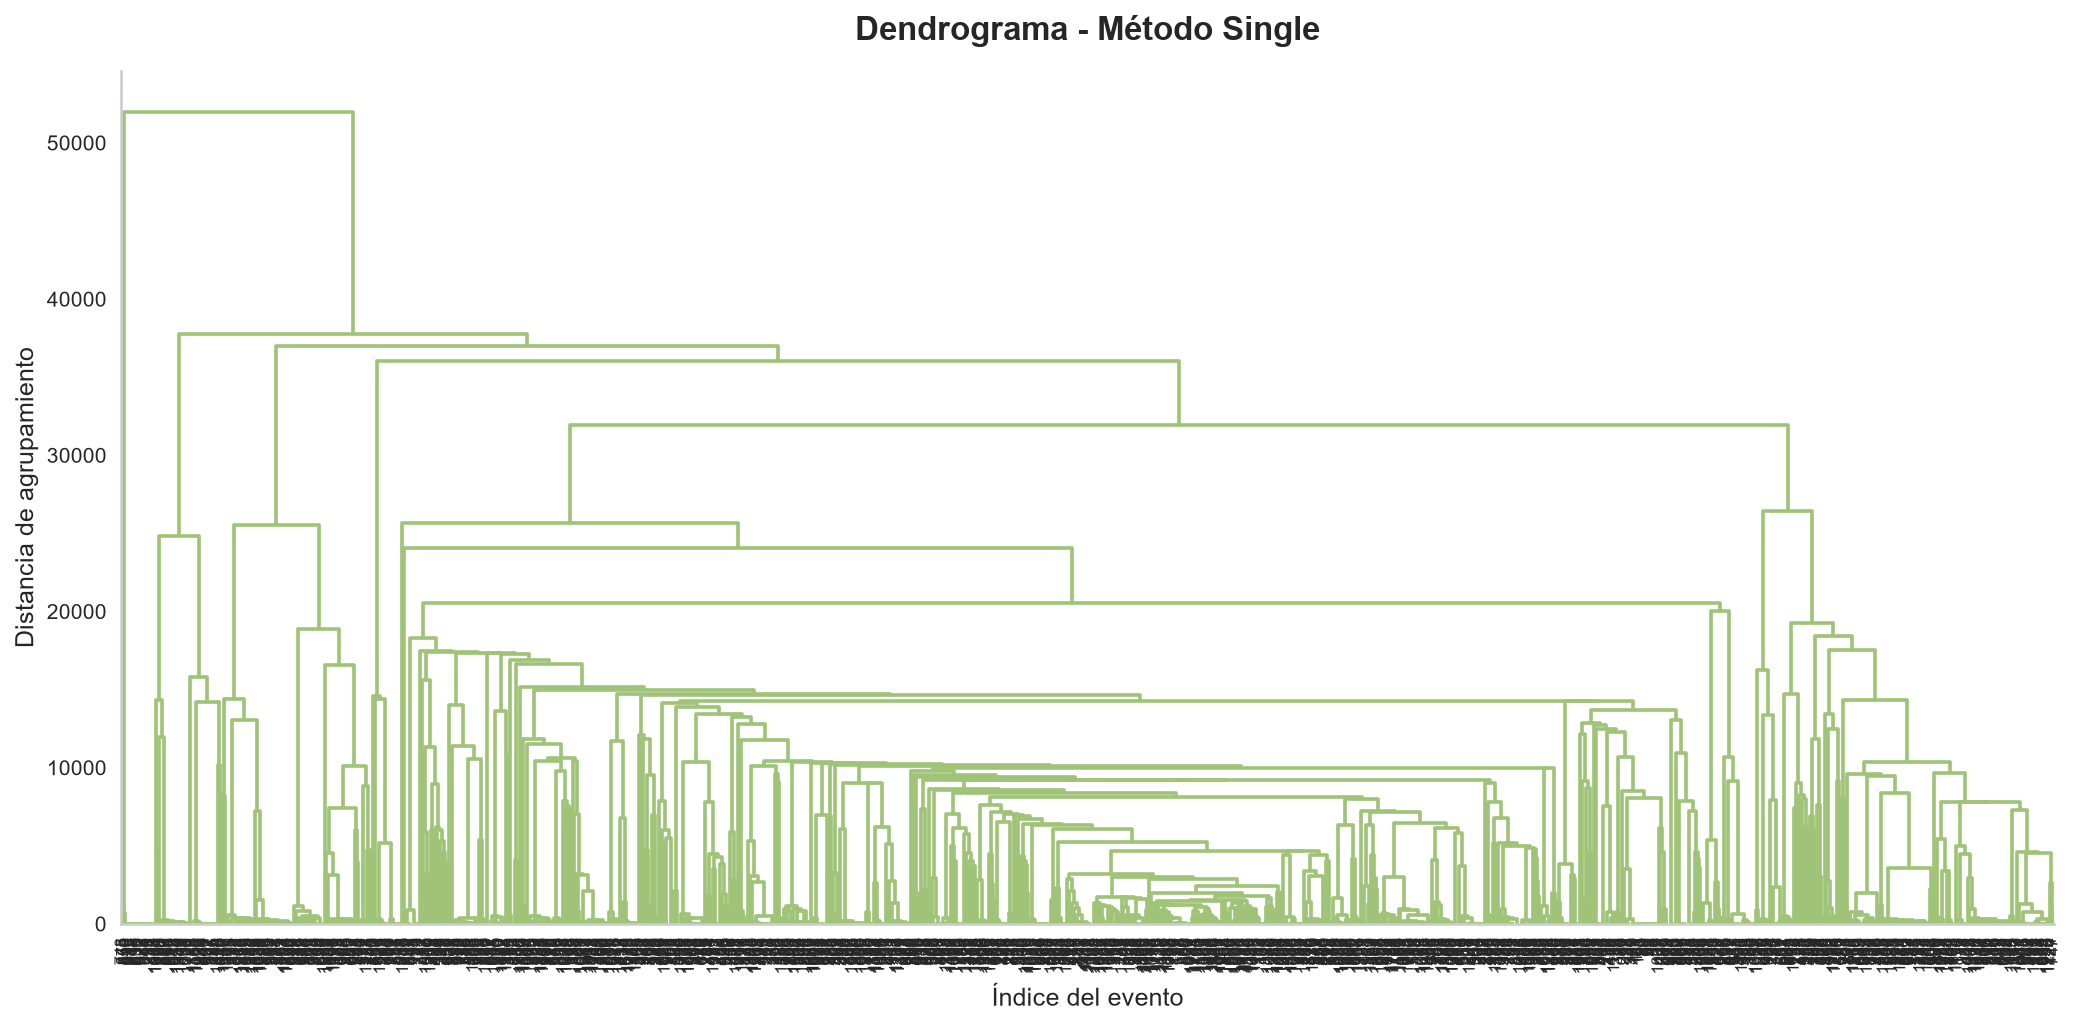

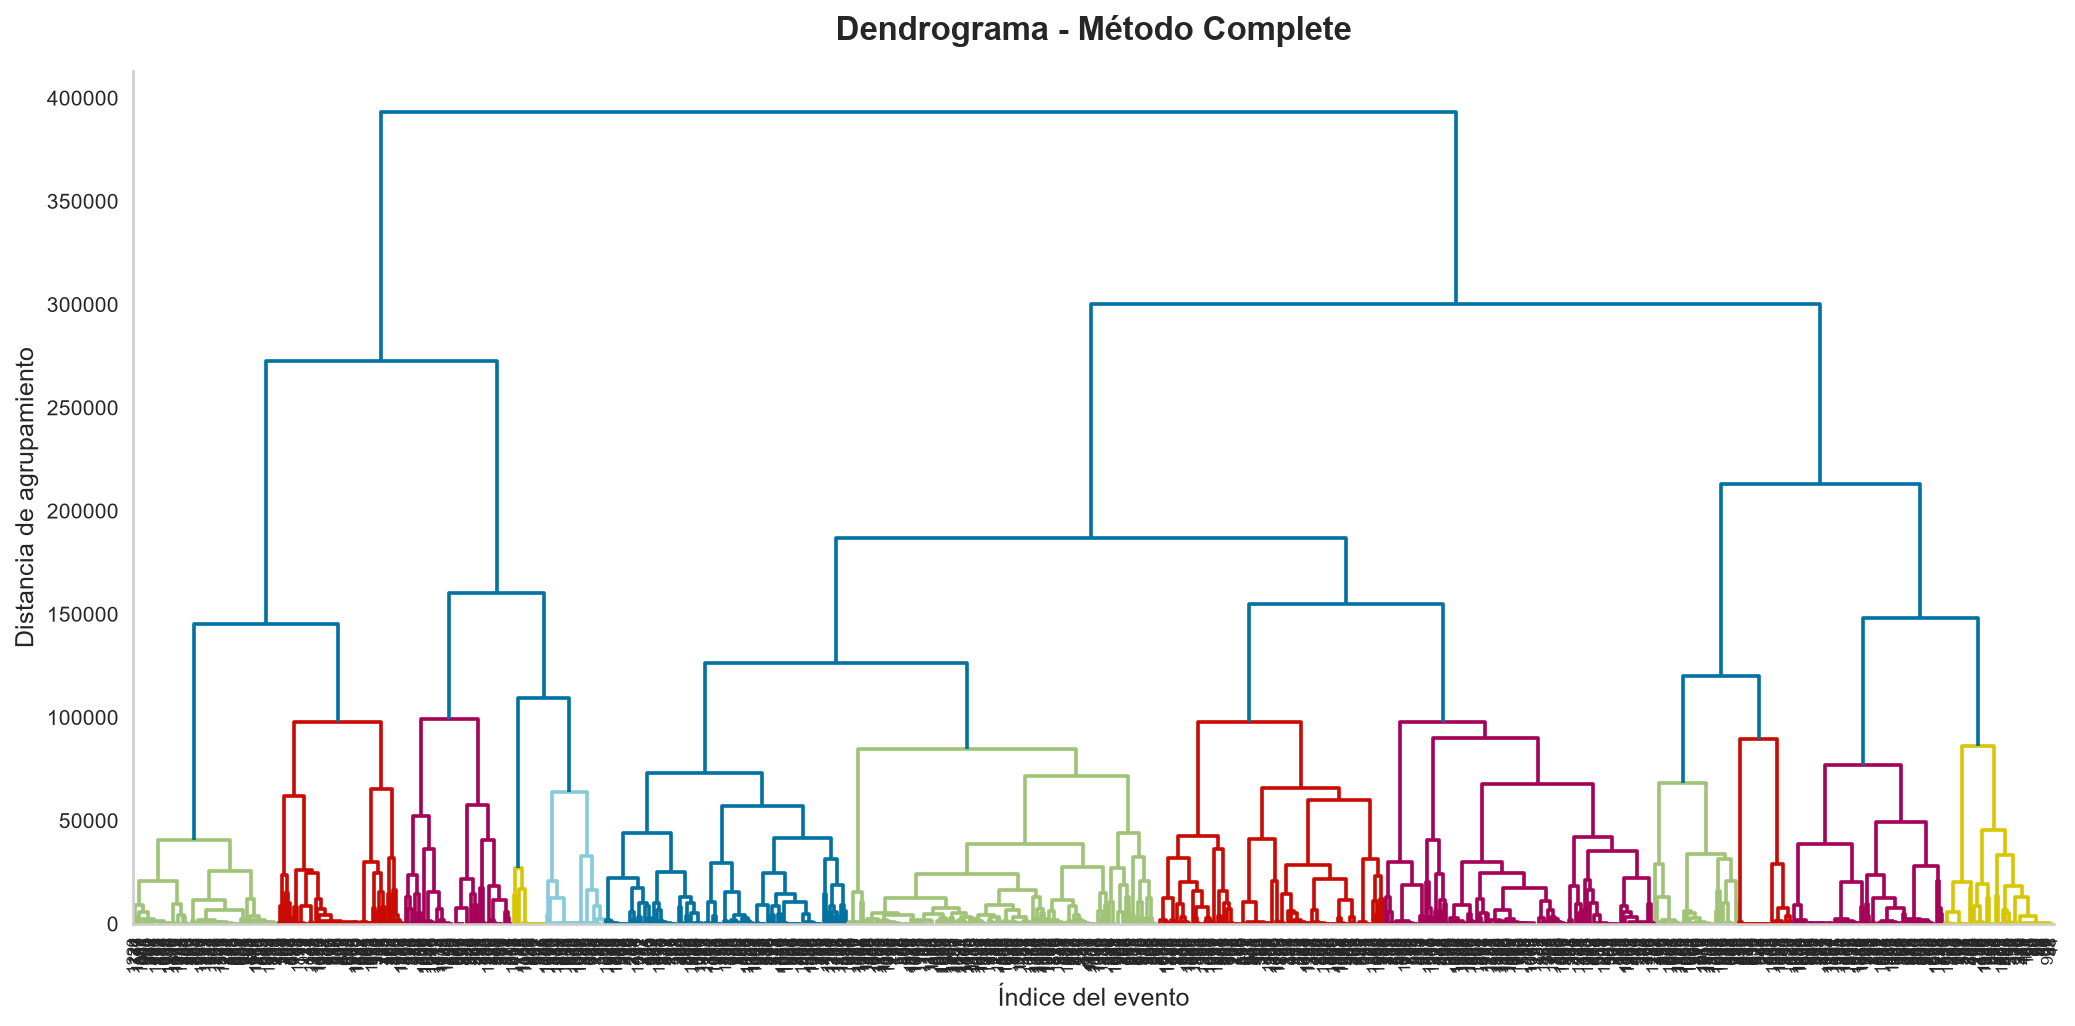

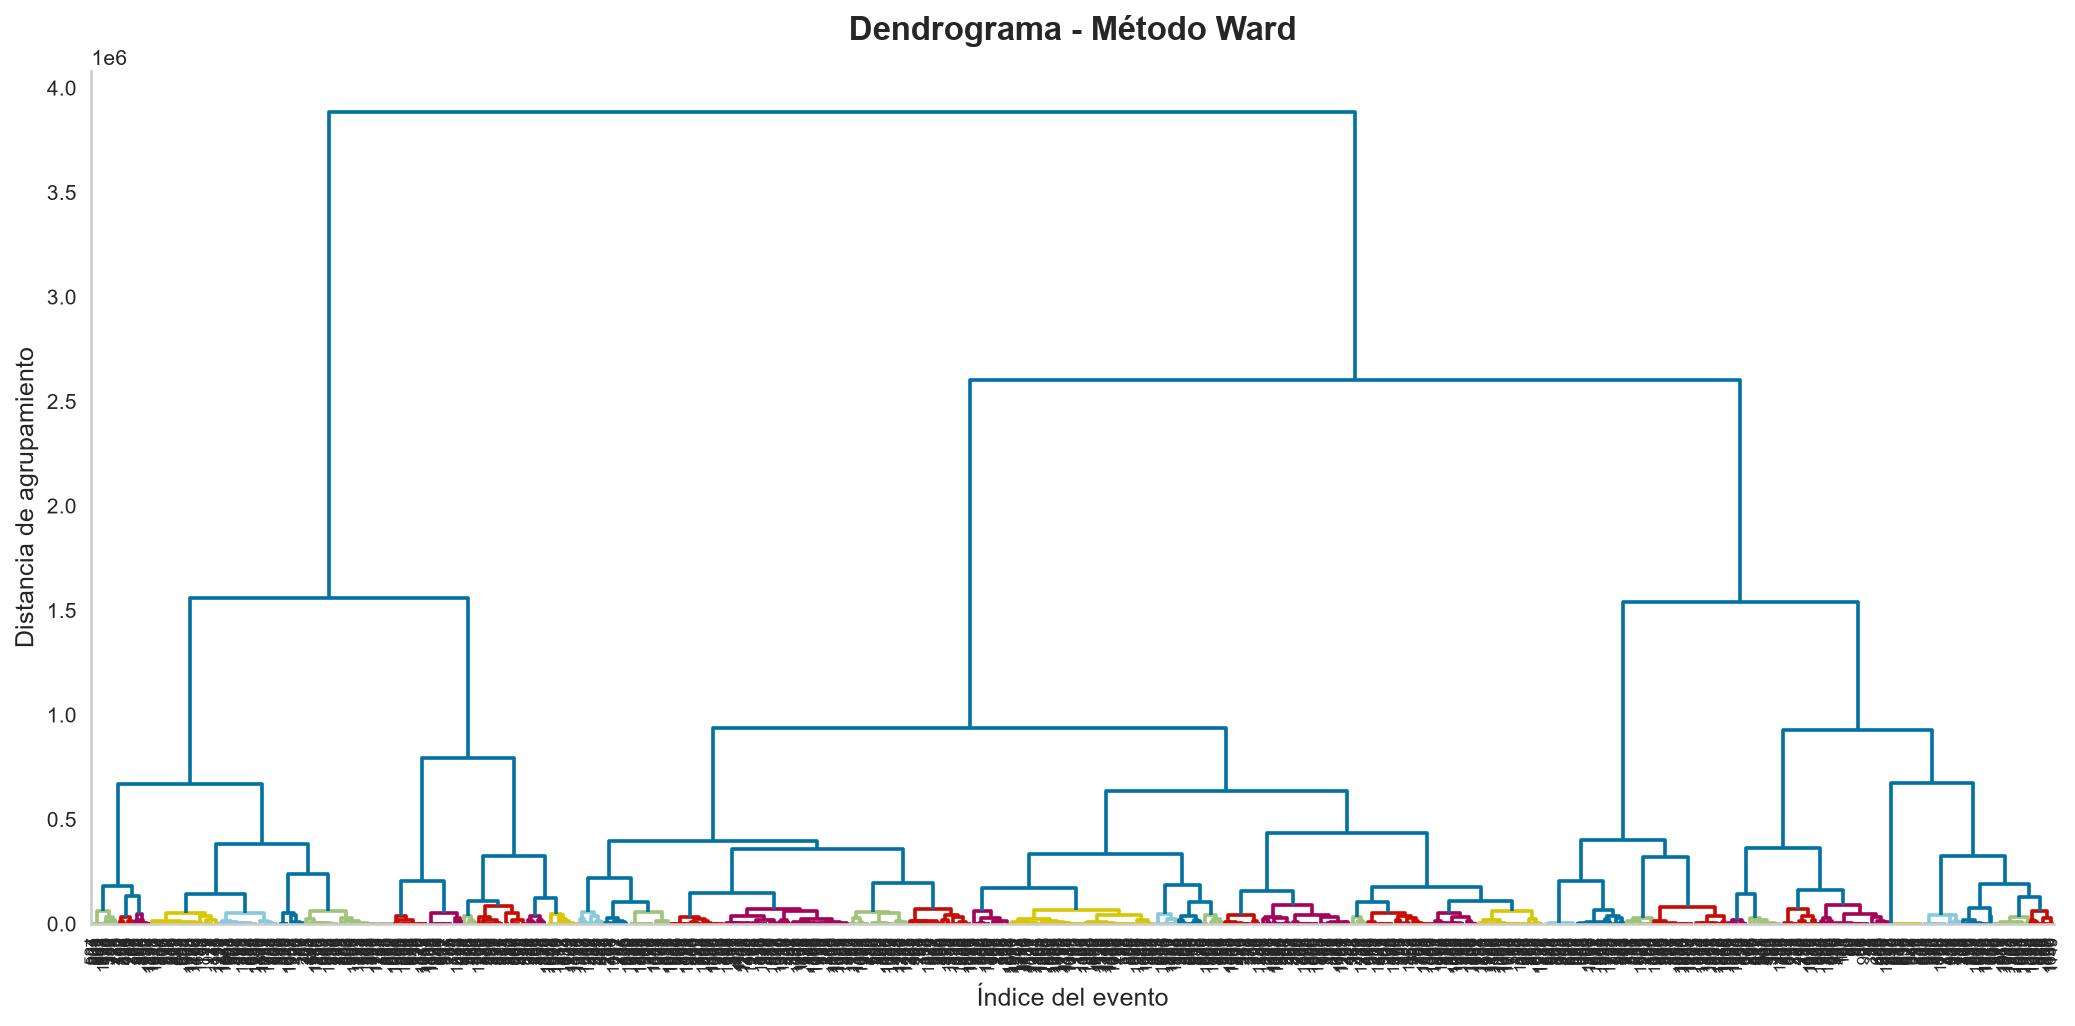

In [32]:
from scipy.cluster import hierarchy
import matplotlib.pyplot as plt

for metodo in ["single","complete", "ward"]:

    Z = hierarchy.linkage(coordenadas, method=metodo)

    fig, ax = plt.subplots(figsize=(14, 7), dpi=150)

    hierarchy.dendrogram(
        Z,
        ax=ax,
        leaf_rotation=90,
        leaf_font_size=8,
        color_threshold=100000,   # Colores automáticos
    )

    # Fondo blanco
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # Títulos
    ax.set_title(
        f"Dendrograma - Método {metodo.capitalize()}",
        fontsize=16,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel("Índice del evento", fontsize=12)
    ax.set_ylabel("Distancia de agrupamiento", fontsize=12)

    # Quitar únicamente el borde superior y derecho
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Sin grilla
    ax.grid(False)

    plt.tight_layout()
    plt.show()

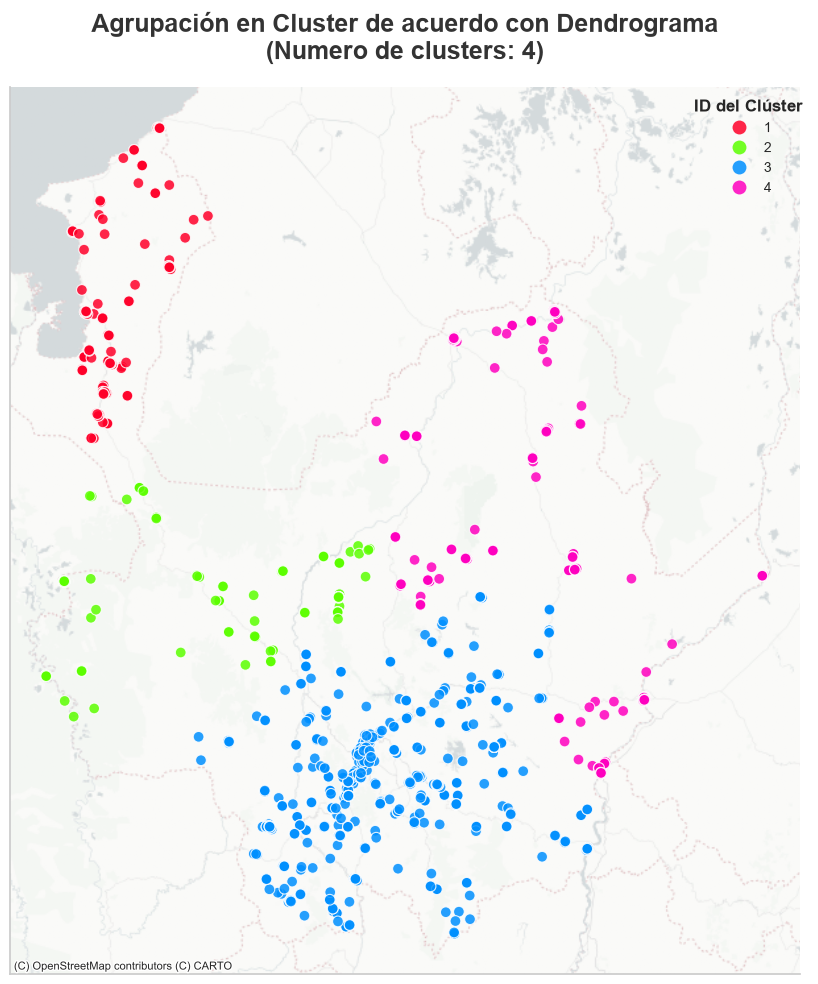

Distribución de eventos de inundación por clúster:
cluster
1    179
2    133
3    694
4    264
Name: count, dtype: int64


In [45]:
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster

# Matriz de enlace usando Complete Linkage
Z = hierarchy.linkage(
    coordenadas,
    method="complete",
    metric="euclidean"
)

# Cortar el dendrograma a 250 km
distancia_corte = 250000  # metros

gdf_proyectado["cluster"] = fcluster(
    Z,
    t=distancia_corte,
    criterion="distance"
).astype(str)

gdf_proyectado['cluster'] = gdf_proyectado['cluster'].astype(int).astype(str) 
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_title(f'Agrupación en Cluster de acuerdo con Dendrograma\n(Numero de clusters: 4)', 
             fontsize=18, fontweight='bold', pad=20, color='#333333')

gdf_proyectado.plot(
    column='cluster',
    categorical=True,
    cmap='gist_rainbow',          
    legend=True,
    markersize=60,
    alpha=0.85,
    edgecolor='white',
    linewidth=0.8,
    ax=ax,
    zorder=5
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zorder=1)

formato_coordenadas = ticker.StrMethodFormatter('{x:,.0f}')
ax.xaxis.set_major_formatter(formato_coordenadas)
ax.yaxis.set_major_formatter(formato_coordenadas)

# 6. Mejorar la Leyenda
leyenda = ax.get_legend()
leyenda.set_title('ID del Clúster', prop={'size': 12, 'weight': 'bold'})
leyenda.get_frame().set_linewidth(0.0)
leyenda.get_frame().set_alpha(0.9)
leyenda.get_frame().set_facecolor('#f9f9f9')

leyenda.set_bbox_to_anchor((1.02, 1))

# 7. Limpieza visual final
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

ax.set_xlabel('Coordenada Este (m)', fontsize=13, color='#555555', labelpad=10)
ax.set_ylabel('Coordenada Norte (m)', fontsize=13, color='#555555', labelpad=10)

# Grilla sutil
ax.grid(linestyle=':', alpha=0.5, color='#999999', zorder=1)

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

# Resumen estadístico
print("Distribución de eventos de inundación por clúster:")
print(gdf_proyectado['cluster'].value_counts().sort_index())

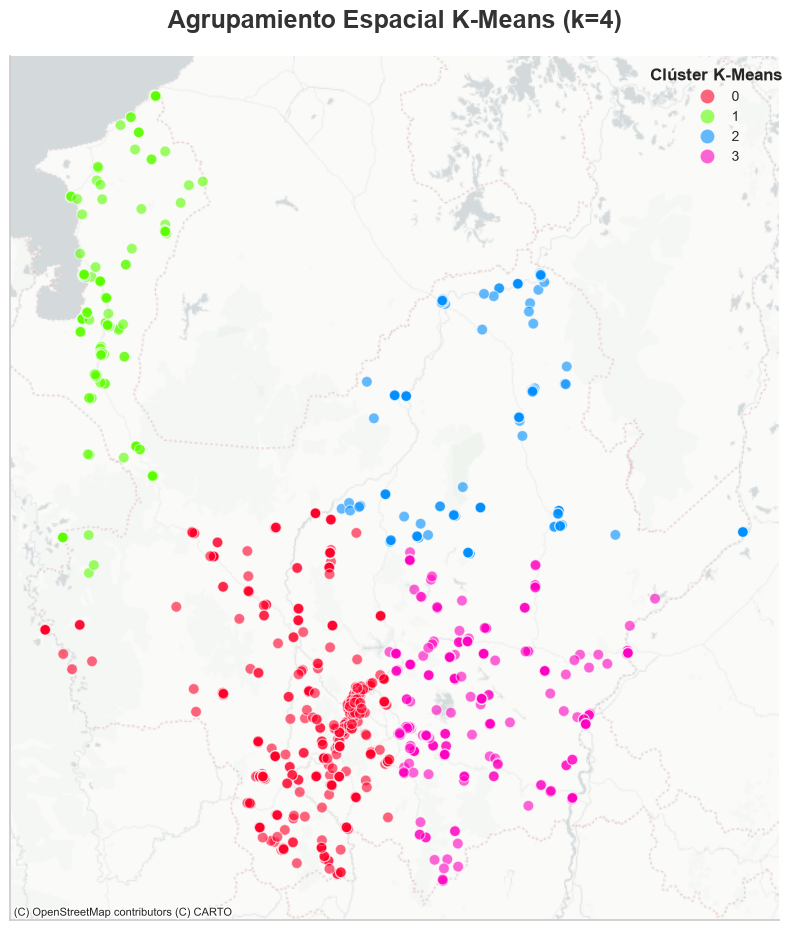

Distribución de eventos por clúster K-Means:
cluster_kmeans
0    499
1    218
2    201
3    352
Name: count, dtype: int64


In [44]:
n_clusters=4
modelo_kmeans = KMeans(n_clusters=n_clusters, n_init='auto', random_state=42)
etiquetas_kmeans = modelo_kmeans.fit_predict(coordenadas)
gdf_proyectado['cluster_kmeans'] = etiquetas_kmeans.astype(str)
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_title(f'Agrupamiento Espacial K-Means (k={n_clusters})', 
             fontsize=18, fontweight='bold', pad=20, color='#333333')

gdf_proyectado.plot(
    column='cluster_kmeans',
    categorical=True,
    cmap='gist_rainbow',
    legend=True,
    markersize=60,         
    alpha=0.6,            
    edgecolor='white',     
    linewidth=0.8,
    ax=ax,
    zorder=5               
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zorder=1)

centroides = modelo_kmeans.cluster_centers_
ax.scatter(centroides[:, 0], centroides[:, 1], 
           marker='X', s=200, c='black', edgecolor='white', linewidth=1.5, 
           zorder=6, label='Centroides')

formato_coordenadas = ticker.StrMethodFormatter('{x:,.0f}')
ax.xaxis.set_major_formatter(formato_coordenadas)
ax.yaxis.set_major_formatter(formato_coordenadas)

leyenda = ax.get_legend()
if leyenda:
    leyenda.set_title('Clúster K-Means', prop={'size': 12, 'weight': 'bold'})
    leyenda.get_frame().set_linewidth(0.0)      
    leyenda.get_frame().set_alpha(0.9)          
    leyenda.get_frame().set_facecolor('#f9f9f9')
    leyenda.set_bbox_to_anchor((1.02, 1))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

ax.set_xlabel('Coordenada Este (m)', fontsize=13, color='#555555', labelpad=10)
ax.set_ylabel('Coordenada Norte (m)', fontsize=13, color='#555555', labelpad=10)

ax.grid(linestyle=':', alpha=0.5, color='#999999', zorder=1)

plt.tight_layout()
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticks([])
ax.set_yticks([])
plt.show()

print("Distribución de eventos por clúster K-Means:")
print(gdf_proyectado['cluster_kmeans'].value_counts().sort_index())

In [17]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

resultados = []

valores_eps = np.arange(1000, 100000, 1000)
valores_min_samples = range(3, 15)

for eps in valores_eps:
    for min_samples in valores_min_samples:

        modelo = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = modelo.fit_predict(coordenadas)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_ruido = np.sum(labels == -1)
        pct_ruido = 100 * n_ruido / len(labels)

        if n_clusters >= 2:
            mask = labels != -1

            if len(np.unique(labels[mask])) >= 2:
                sil = silhouette_score(coordenadas[mask], labels[mask])
            else:
                sil = np.nan
        else:
            sil = np.nan

        resultados.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "pct_ruido": pct_ruido,
            "silhouette": sil
        })

df_dbscan = pd.DataFrame(resultados)

df_dbscan_ordenado = (
    df_dbscan
    .dropna()
    .sort_values(
        by=["silhouette", "pct_ruido"],
        ascending=[False, True]
    )
)

display(df_dbscan_ordenado.head(20))

,eps,min_samples,n_clusters,pct_ruido,silhouette
11,1000,14,22,67.559055,0.980429
9,1000,12,25,64.330709,0.979637
10,1000,13,25,64.330709,0.979637
8,1000,11,28,61.732283,0.978874
6,1000,9,38,54.015748,0.970724
7,1000,10,33,57.795276,0.970649
5,1000,8,45,49.448819,0.961309
4,1000,7,55,43.779528,0.953070
3,1000,6,62,40.157480,0.946761
1,1000,4,93,29.291339,0.939762


eps óptimo: 27000.0
min_samples óptimo: 3
cluster_dbscan
0    890
1     99
2    196
3     22
4     44
5     19
Name: count, dtype: int64


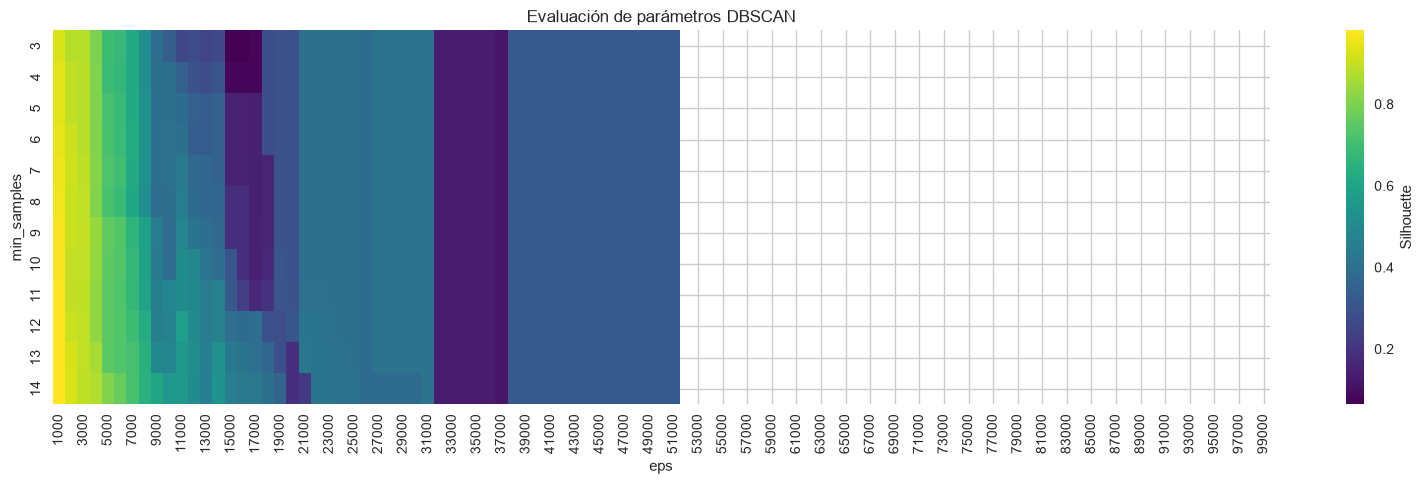

In [ ]:
df_filtrado = df_dbscan[
    (df_dbscan["n_clusters"] >= 3) &
    (df_dbscan["n_clusters"] <= 8) &
    (df_dbscan["pct_ruido"] <= 25) &
    (df_dbscan["silhouette"].notna())
].copy()

mejor = df_filtrado.sort_values(
    by=["silhouette", "pct_ruido"],
    ascending=[False, True]
).iloc[0]

mejor
eps_optimo = mejor["eps"]
min_samples_optimo = int(mejor["min_samples"])

modelo_dbscan = DBSCAN(
    eps=eps_optimo,
    min_samples=min_samples_optimo
)

gdf_proyectado["cluster_dbscan"] = modelo_dbscan.fit_predict(coordenadas)

print("eps óptimo:", eps_optimo)
print("min_samples óptimo:", min_samples_optimo)
print(gdf_proyectado["cluster_dbscan"].value_counts().sort_index())

import seaborn as sns
import matplotlib.pyplot as plt

tabla_heatmap = df_dbscan.pivot(
    index="min_samples",
    columns="eps",
    values="silhouette"
)

plt.figure(figsize=(16, 5))
sns.heatmap(
    tabla_heatmap,
    cmap="viridis",
    cbar_kws={"label": "Silhouette"}
)

plt.xlabel("eps")
plt.ylabel("min_samples")
plt.title("Evaluación de parámetros DBSCAN")
plt.tight_layout()
plt.show()

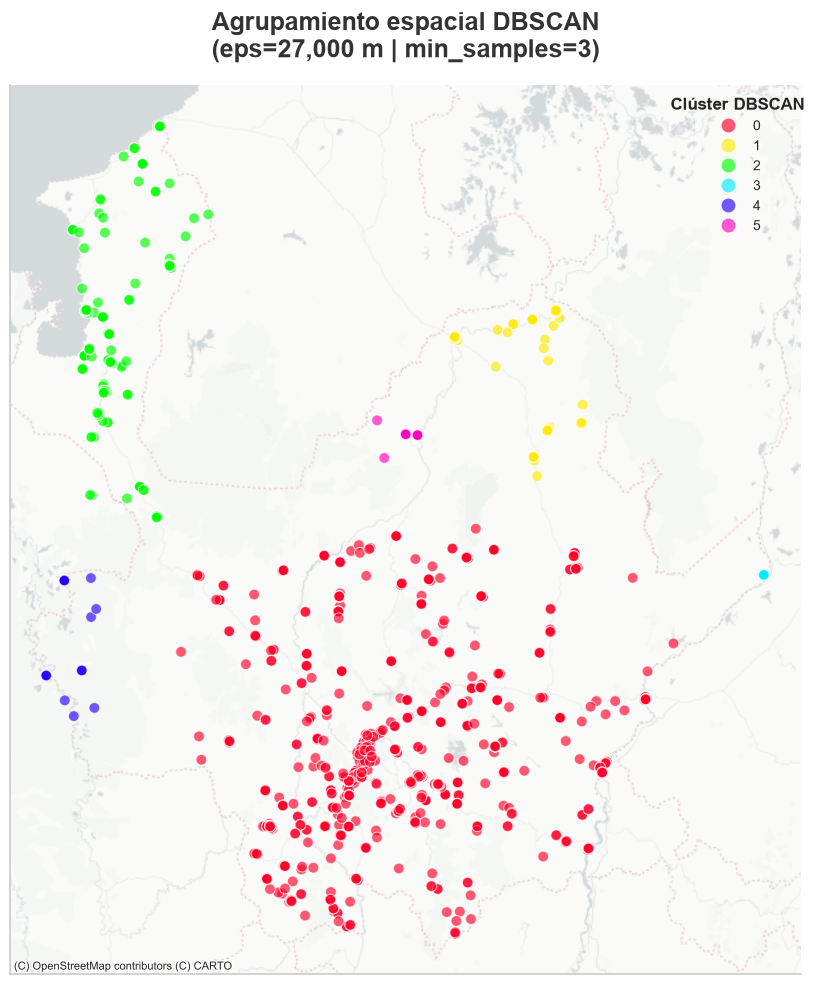

Distribución de eventos por clúster DBSCAN:
cluster_dbscan
0    890
1     99
2    196
3     22
4     44
5     19
Name: count, dtype: int64


In [ ]:
eps = 27000          # radio en metros
min_samples = 3      # mínimo de puntos

modelo_dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples
)

etiquetas_dbscan = modelo_dbscan.fit_predict(coordenadas)

gdf_proyectado["cluster_dbscan"] = etiquetas_dbscan.astype(str)
gdf_proyectado.loc[etiquetas_dbscan == -1, "cluster_dbscan"] = "Ruido"

# ==========================
# Gráfica
# ==========================
fig, ax = plt.subplots(figsize=(12, 10))

ax.set_title(
    f"Agrupamiento espacial DBSCAN\n(eps={eps:,.0f} m | min_samples={min_samples})",
    fontsize=18,
    fontweight="bold",
    pad=20,
    color="#333333"
)

gdf_proyectado.plot(
    column="cluster_dbscan",
    categorical=True,
    cmap="gist_rainbow",
    legend=True,
    markersize=60,
    alpha=0.65,
    edgecolor="white",
    linewidth=0.8,
    ax=ax,
    zorder=5
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.PositronNoLabels,
    zorder=1
)

formato_coordenadas = ticker.StrMethodFormatter("{x:,.0f}")
ax.xaxis.set_major_formatter(formato_coordenadas)
ax.yaxis.set_major_formatter(formato_coordenadas)

leyenda = ax.get_legend()
if leyenda:
    leyenda.set_title("Clúster DBSCAN", prop={"size": 12, "weight": "bold"})
    leyenda.get_frame().set_linewidth(0.0)
    leyenda.get_frame().set_alpha(0.9)
    leyenda.get_frame().set_facecolor("#f9f9f9")
    leyenda.set_bbox_to_anchor((1.02, 1))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticks([])
ax.set_yticks([])

ax.grid(linestyle=":", alpha=0.5, color="#999999", zorder=1)

plt.tight_layout()
plt.show()

print("Distribución de eventos por clúster DBSCAN:")
print(gdf_proyectado["cluster_dbscan"].value_counts().sort_index())